In [55]:
from langchain_community.document_loaders import DirectoryLoader

pdfs = DirectoryLoader("documentos", glob="*.pdf").load()

len(pdfs)

No languages specified, defaulting to English.
No languages specified, defaulting to English.
No languages specified, defaulting to English.


3

In [56]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

In [57]:
from langchain_text_splitters import CharacterTextSplitter

splitter = CharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer=tokenizer, chunk_size=1250, chunk_overlap=150
)

pedacos = splitter.split_documents(pdfs)
len(pedacos)

37

In [58]:
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="bge-m3:567m")

vector_store = FAISS.from_documents(
    documents=pedacos, embedding=embeddings
)

retriever = vector_store.as_retriever()

In [59]:
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Responda usando exclusivamente o conteúdo fornecido. Seja breve na resposta.\n\nContexto: \n{contexto}"),
        ("human", "{query}")
    ]
)

modelo = OllamaLLM(model="gemma3:4b")

In [60]:
import getpass
import os
from langsmith import traceable

langsmith_tracing = os.getenv("LANGSMITH_TRACING")
if not langsmith_tracing:
    langsmith_api_key = getpass.getpass("Enter your LANGSMITH_TRACING: ")

langsmith_api_key = os.getenv("LANGSMITH_API_KEY")
if not langsmith_api_key:
    langsmith_api_key = getpass.getpass("Enter your LANGSMITH_API_KEY: ")

In [61]:
# @traceable
# def rag_trace(pergunta):
#   cadeia = prompt | modelo | StrOutputParser()
#   # retrieve
#   trechos = retriever.invoke(pergunta)
#   # augment
#   contexto = "\n\n".join(um_trecho.page_content for um_trecho in trechos)
#   # generate
#   return cadeia.invoke({ "query": pergunta, "contexto": contexto})

In [62]:
# pergunta = "Como fazer um seguro viagem?"

# rag_trace(pergunta)

In [63]:
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"contexto": RunnablePassthrough()  | retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | modelo | StrOutputParser()
)

In [64]:
rag_chain.invoke("Como fazer um seguro viagem?")

'Com base nos documentos fornecidos, aqui estão os passos para obter o seguro viagem MasterAssist Plus™:\n\n1.  **Ser Portador do Cartão Mastercard Platinum™:** Você precisa ser portador do cartão Mastercard Platinum™ para ter acesso a esse programa de seguro. Além disso, sua família (cônjuge, companheiro(a) e filhos dependentes) também pode se beneficiar, desde que estejam incluídos no Bilhete de Seguro Anual.\n\n2.  **Reemitir o Bilhete de Seguro:** Se houver alguma mudança em seus dependentes (cônjuge, companheiro(a) ou filho(s)), você precisa reemitir o seu Bilhete de Seguro atualizado para garantir que eles continuem cobertos.\n\n3.  **Coberturas:** O seguro oferece cobertura para:\n    *   Despesas médicas e hospitalares em viagem ao exterior (acidente ou doença súbita)\n    *   Traslado médico (remoção médica)\n    *   Traslado de corpo (repatriação funerária)\n    *   Retorno de menores/idosos\n    *   Acompanhante em caso de hospitalização prolongada\n    *   Hospedagem\n\n4. 

## Resultado da consulta pura (consulta sem nenhuma tratamento)

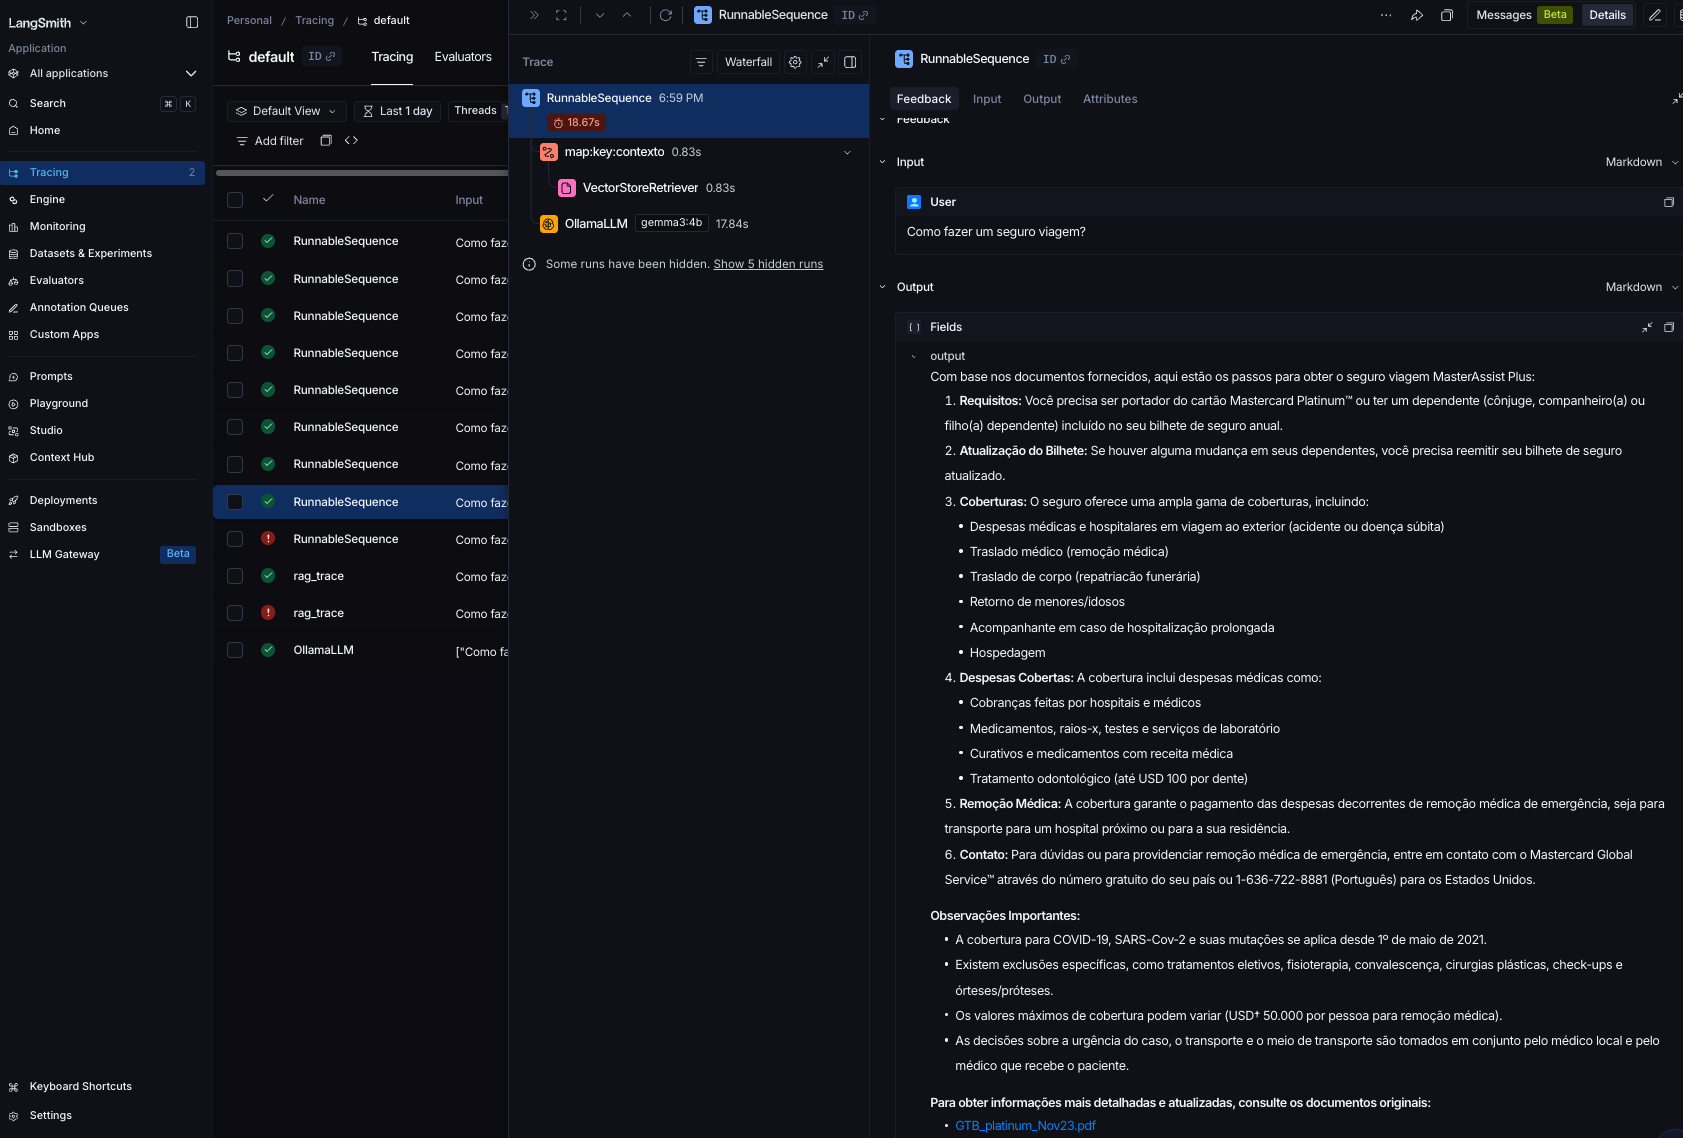

## Question transformations - Rewrite-Retrieve-Read

![image.png](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*wOQsUx-_JRs4zhp7u77Tsw.png)

In [65]:
# from langchain_core.prompts import PromptTemplate

# query_model = OllamaLLM(model="gemma3:1b")

# pergunta = "Como fazer um seguro viagem?"

# rewriter_prompt_template = """
# Gere consulta de pesquisa para o banco de dados de vetores (Vector DB) a partir de uma pergunta do usuário,
# permitindo uma resposta mais precisa por meio da busca semântica.
# Basta retornar a consulta revisada do Vector DB, entre aspas.

# Pergunta do usuário: {user_question}
# Consulta revisada do Vector DB:
# """

# rewriter_prompt = PromptTemplate.from_template(rewriter_prompt_template)
# rewriter_chain = rewriter_prompt | query_model | StrOutputParser()

# rewriter_chain.invoke(pergunta)

## Resultado da consulta enriquecida usando o modelo Gemma3:1b

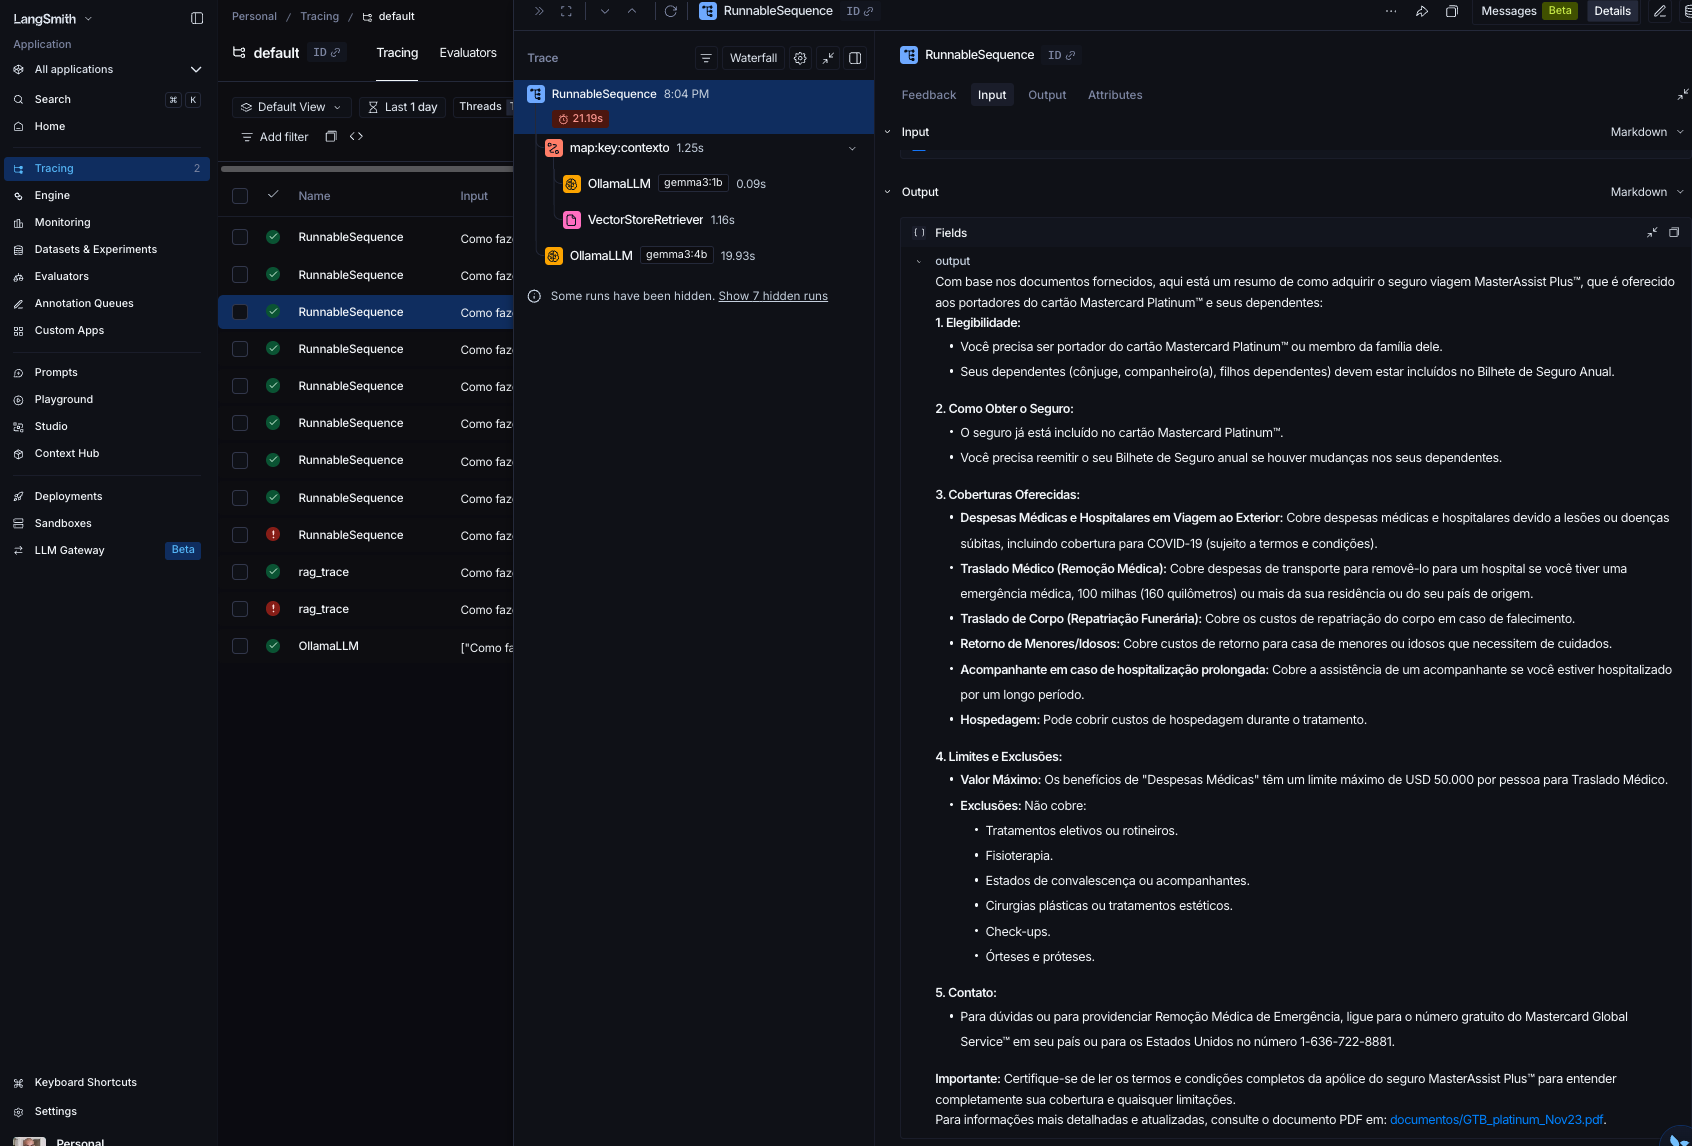

In [66]:
from langchain_core.prompts import PromptTemplate

query_model = OllamaLLM(model="gemma3:1b")

pergunta = "Como fazer um seguro viagem?"

rewriter_prompt_template = """
Gere consulta de pesquisa para o banco de dados de vetores (Vector DB) a partir de uma pergunta do usuário,
permitindo uma resposta mais precisa por meio da busca semântica.
Basta retornar a consulta revisada do Vector DB, entre aspas.

Pergunta do usuário: {user_question}
Consulta revisada do Vector DB:
"""

rewriter_prompt = PromptTemplate.from_template(rewriter_prompt_template)
rewriter_chain = rewriter_prompt | modelo | StrOutputParser()

rewriter_chain.invoke(pergunta)

'"seguro viagem processo compra requisitos cobertura"\n'

In [67]:
rewriter_rag_chain = (
    {"contexto": RunnablePassthrough()  | rewriter_chain | retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | modelo | StrOutputParser()
)

In [68]:
rewriter_rag_chain.invoke(pergunta)

'Para adquirir o seguro viagem MasterAssist Plus, siga estes passos:\n\n1.  **Compre um cartão Mastercard Gold:** O seguro é oferecido através da compra de um cartão Mastercard Gold.\n2.  **Acesse o portal:** Acesse o site [www.aig.com/Mastercard/pt](http://www.aig.com/Mastercard/pt).\n3.  **Emita o Bilhete de Seguro:** Através deste portal, você emitirá o Bilhete de Seguro, que formaliza a cobertura para a Pessoa Segurada.\n\n**Importante:**\n\n*   A emissão do Bilhete de Seguro é crucial para ter cobertura.\n*   A cobertura é válida para compras feitas integralmente com o seu cartão Mastercard Gold e/ou adquiridas com pontos ganhos.\n*   Para ser elegível para a cobertura, você deve pagar todos os impostos, taxas de transporte, manuseio e outras taxas exigidas com o cartão Mastercard.\n\n**Se você tiver perguntas ou precisar de ajuda para usar os serviços sem desembolso de dinheiro**, consulte a seção "Mastercard Global Service" no guia.  Você pode também entrar em contato com o Mast

## Resultado da consulta enriquecida usando o modelo Gemma3:4b

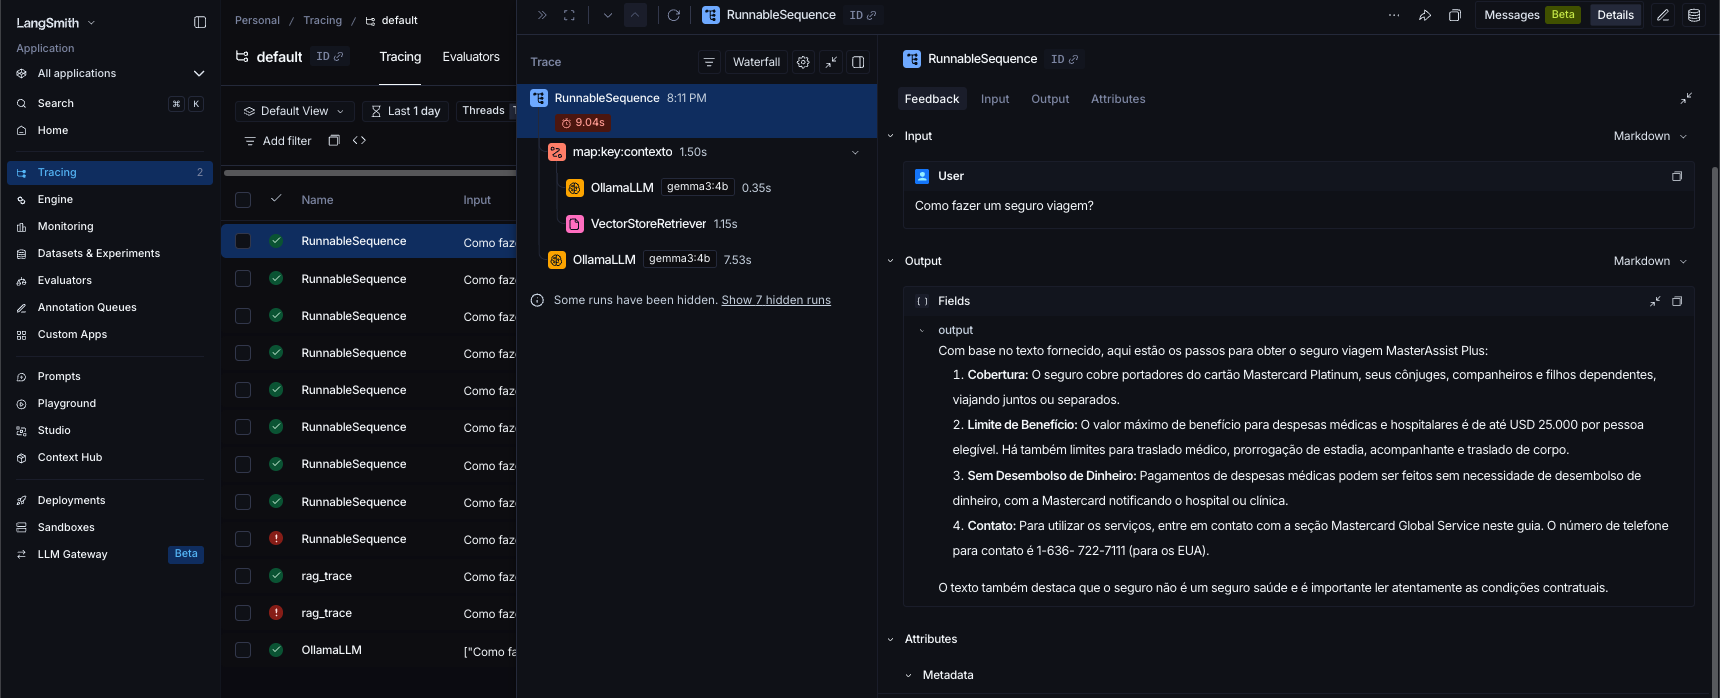

## Generating multiple queries

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*z1EuCfvPHtmISs0dldU1Tw.png)

In [69]:
# Exemplo com modelo Gemma3:4b

from langchain_core.output_parsers import CommaSeparatedListOutputParser
from langchain_openai import ChatOpenAI

multi_query_prompt_template = """Você é um assistente de modelo de linguagem de IA. Sua tarefa é gerar cinco
versões diferentes da pergunta do usuário para recuperar documentos relevantes de um banco de dados vetorial.
Ao gerar múltiplas perspectivas sobre a pergunta do usuário, seu objetivo é ajudar
o usuário a superar algumas das limitações da busca por similaridade baseada em distância.
Forneça estas perguntas alternativas separadas por quebras de linha.
Pergunta original: {question}"""

multi_query_prompt = PromptTemplate.from_template(multi_query_prompt_template)

multi_query_chain = multi_query_prompt | modelo | CommaSeparatedListOutputParser()

print(pergunta)
multi_query_chain.invoke(pergunta)

Como fazer um seguro viagem?


['Aqui estão cinco versões alternativas da pergunta "Como fazer um seguro viagem?"',
 'projetadas para gerar resultados mais diversos em um banco de dados vetorial:',
 '1.  Processo de compra de apólices de seguro de viagem: Quais são os passos detalhados para adquirir um seguro viagem',
 'desde a avaliação das necessidades até a conclusão da compra?',
 '2.  Comparando opções de seguro viagem: Como comparar diferentes seguradoras e planos de seguro de viagem para encontrar o melhor custo-benefício para uma viagem específica?',
 '3.  Coberturas essenciais de um seguro viagem: Quais são os elementos cruciais que devem ser incluídos em um seguro viagem para cobrir emergências médicas',
 'perda de bagagem',
 'cancelamento de viagem e outras situações inesperadas?',
 '4.  Requisitos e documentos para seguro viagem: Quais documentos e informações são necessários para contratar um seguro viagem',
 'e quais são as condições para cobertura em diferentes países?',
 '5.  Seguro viagem para [desti

In [70]:
# Exemplo com modelo GPT-4.1-nano

from langchain_core.output_parsers import CommaSeparatedListOutputParser
from langchain_openai import ChatOpenAI

openai_api_key = os.getenv("OPENAI_API_KEY")

multi_query_prompt_template = """Você é um assistente de modelo de linguagem de IA. Sua tarefa é gerar cinco
versões diferentes da pergunta do usuário para recuperar documentos relevantes de um banco de dados vetorial.
Ao gerar múltiplas perspectivas sobre a pergunta do usuário, seu objetivo é ajudar
o usuário a superar algumas das limitações da busca por similaridade baseada em distância.
Forneça estas perguntas alternativas separadas por quebras de linha.
Pergunta original: {question}"""

multi_query_prompt = PromptTemplate.from_template(multi_query_prompt_template)

gpt = ChatOpenAI(model="gpt-4.1-nano", temperature=0, api_key=openai_api_key)

multi_query_chain = multi_query_prompt | gpt | CommaSeparatedListOutputParser()

print(pergunta)
multi_query_chain.invoke(pergunta)

Como fazer um seguro viagem?


['Quais são os passos necessários para contratar um seguro viagem?  ',
 'O que devo considerar ao fazer um seguro para minha viagem?  ',
 'Como posso obter um seguro viagem adequado às minhas necessidades?  ',
 'Quais documentos ou informações são importantes ao solicitar um seguro de viagem?  ',
 'Quais são as principais coberturas oferecidas por um seguro viagem e como escolhê-las?']

In [71]:
from langchain_classic.retrievers import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever(
    retriever=retriever,
    llm_chain=multi_query_chain
)

multi_rag_chain = (
    {"contexto": RunnablePassthrough()  | multi_query_retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | modelo | StrOutputParser()
)

In [72]:
multi_rag_chain.invoke(pergunta)

'Com base no documento fornecido, aqui estão os passos e informações relevantes sobre como obter o seguro viagem através do Mastercard Platinum:\n\n**Cobertura de Emergência Médica (MasterAssist Plus):**\n\n1.  **Condições para Cobertura:**\n    *   A cobertura é para tratamento médico adicional ou recuperação, ou ambos.\n    *   As despesas devem ser incorridas a 100 milhas (160 quilômetros) ou mais de distância da residência ou fora do seu País de Origem.\n2.  **Tomada de Decisão Médica:**\n    *   Uma decisão sobre a urgência do caso, a melhor hora e o meio de transporte mais conveniente será tomada pelo médico local que atendeu o paciente e pelo médico que o recebeu.\n3.  **Contato para Assistência:**\n    *   Ligue para o número de discagem gratuita do Mastercard Global Service™ no seu país (ex: 1-636-722-8881 para os EUA).\n    *   Para o Brasil, o número é 0800-725-2025.\n\n**Cobertura de Transporte Especial:**\n\n*   **Requisitos:** As despesas devem ser recomendadas pelo médic

## Resultado da consulta com Multi Query

### 7 documentos retornados
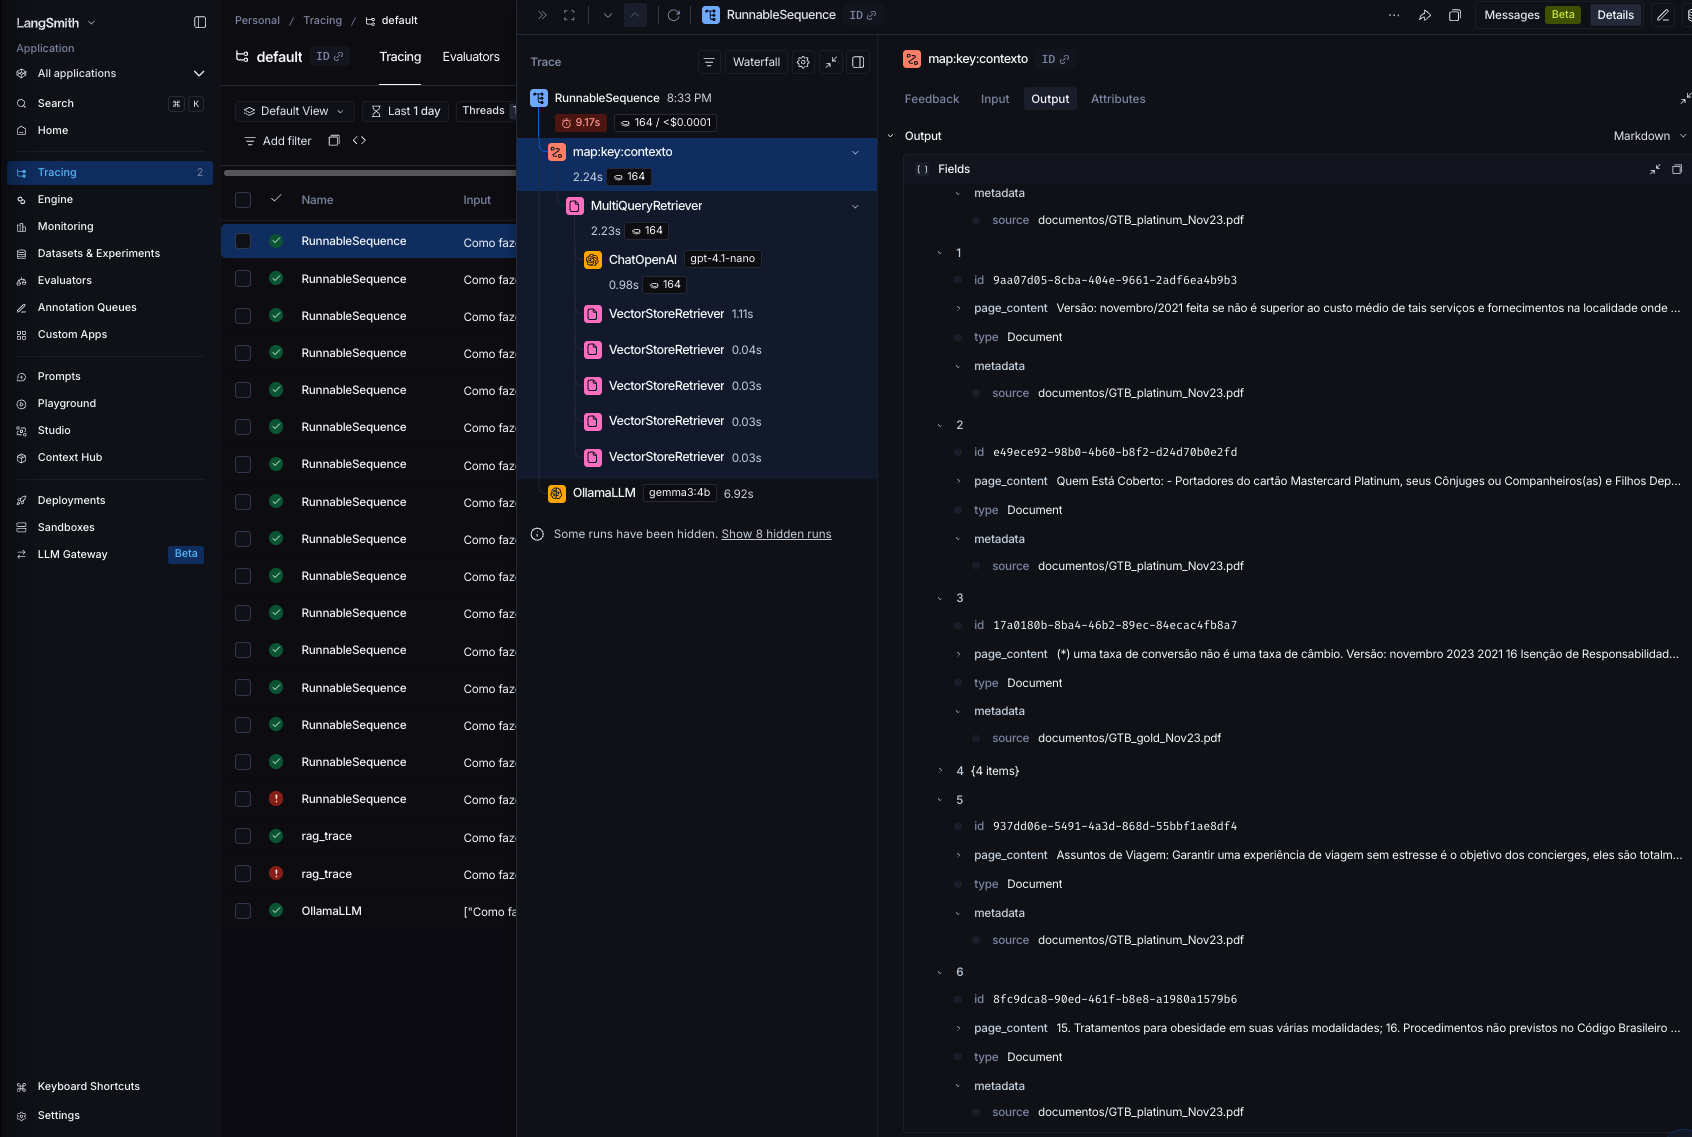

### Output
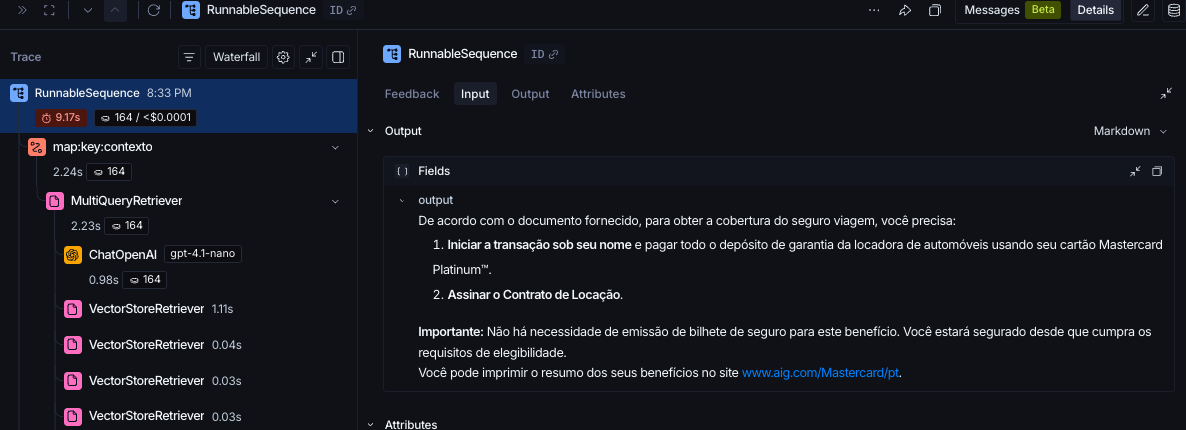

## Hypothetical Document Embeddings (HyDE)

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*akOv9WTwCEdnTgM5VMIi9A.png)

In [73]:
hyde_prompt_template = """
Escreva um paragrafo de até 200 palavras que possa responder à pergunta apresentada. Não adicione mais nada.
Pergunta: {query}
Paragrafo:
"""

hyde_prompt = PromptTemplate.from_template(hyde_prompt_template)

hyde_chain = hyde_prompt | gpt | StrOutputParser()

hyde_chain.invoke(pergunta)

'Para fazer um seguro viagem, primeiro pesquise e compare as opções disponíveis no mercado, levando em consideração cobertura, valores e reputação da seguradora. É importante verificar se o plano inclui assistência médica, odontológica, repatriação, perda de bagagem e cancelamento de viagem. Ao escolher a apólice, leia atentamente as condições gerais e exclusões para evitar surpresas. Após a seleção, preencha o formulário de contratação com seus dados pessoais, informações do destino e datas da viagem. Geralmente, o pagamento pode ser feito por cartão de crédito ou débito, e a emissão do documento é rápida, muitas vezes instantânea. Recomenda-se guardar uma cópia do seguro, além de anotar o número de contato de emergência da seguradora. Se necessário, entre em contato para esclarecer dúvidas ou solicitar assistência antes ou durante a viagem. Planejar com antecedência e garantir uma cobertura adequada proporcionam tranquilidade e segurança, permitindo aproveitar a viagem sem preocupaçõ

## Output do Hyde sem contexto

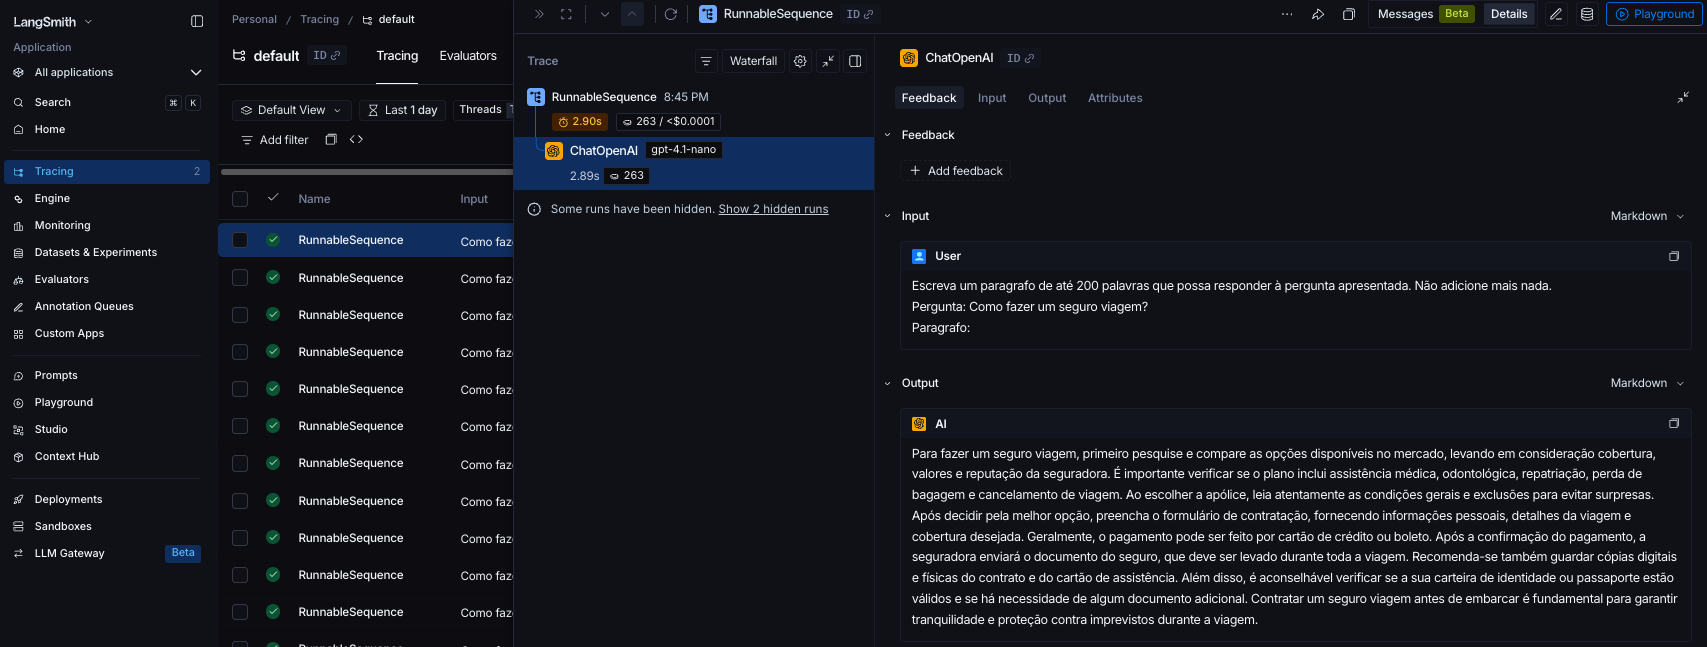

In [74]:
hyde_rag_chain = (
    {"contexto": RunnablePassthrough()  | hyde_chain | retriever, 
     "query": RunnablePassthrough()
    }
    | prompt | gpt | StrOutputParser()
)

hyde_rag_chain.invoke(pergunta)

'Para fazer um seguro viagem, você deve adquirir o Bilhete de Seguro através do portal www.aig.com/Mastercard/pt, que deve ser apresentado em caso de sinistro. A cobertura é válida por 12 meses e cobre despesas médicas, assistência de viagem, traslado médico, entre outros benefícios, desde que a passagem seja cobrada do seu cartão Mastercard PlatinumTM ou adquirida com pontos de programas de recompensas.'

## Output do hyde com contexto

### Documento gerado a partir da pergunta
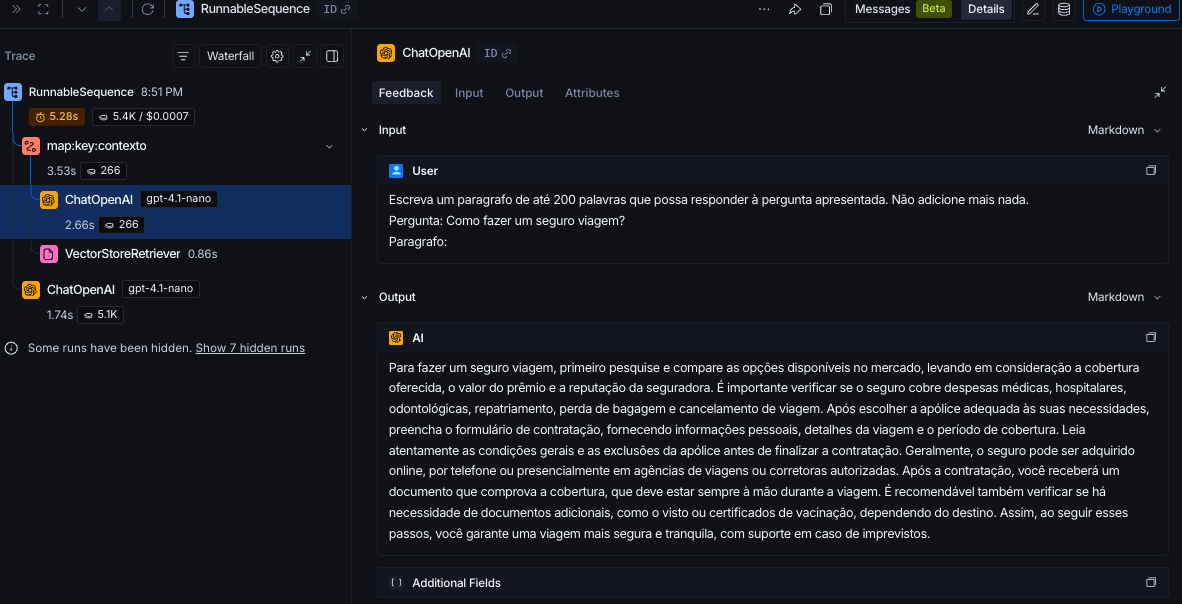

### Documentos retornados na consulta do VectorDB
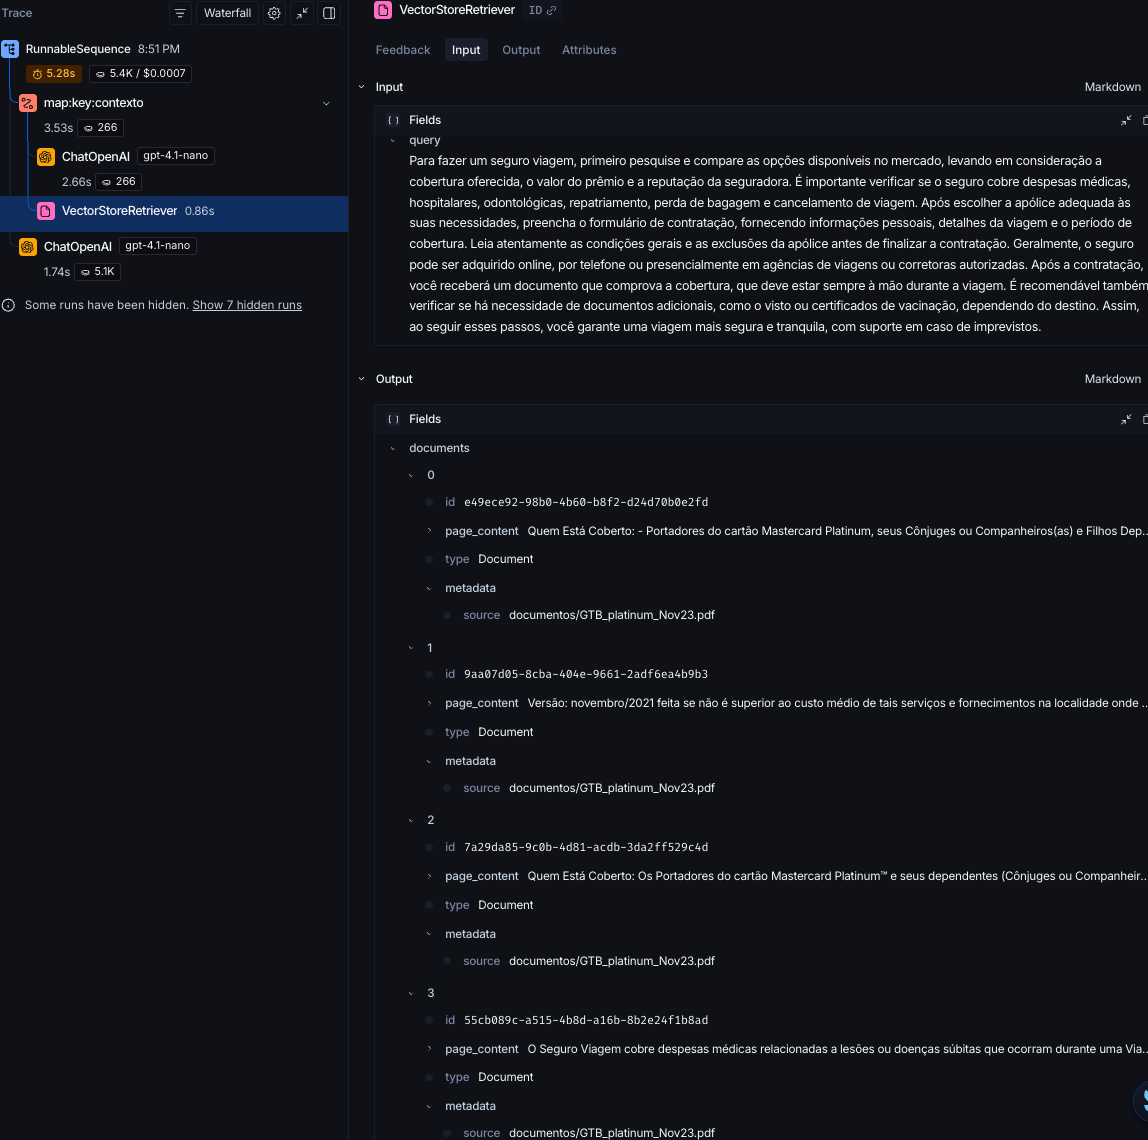

### Output
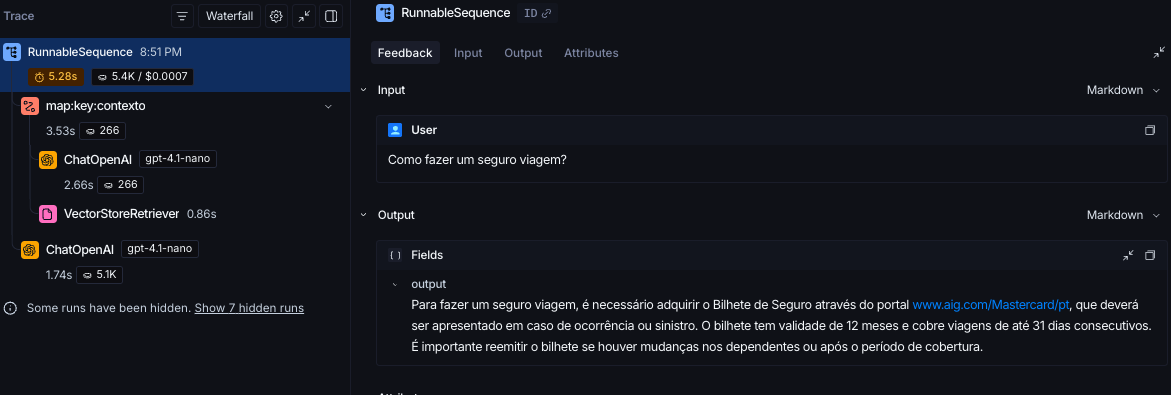


## Validações

In [75]:
from langchain_classic.evaluation.qa import QAEvalChain

eval_chain = QAEvalChain.from_llm(gpt)

def avaliar(perguntas_respostas, geracoes):
    # perguntas_respostas: query, answer
    # geracoes: resultado
    avaliacoes = eval_chain.evaluate(perguntas_respostas, geracoes)
    corretas = 0
    for i, e in enumerate(perguntas_respostas):
        print(avaliacoes[i]["results"].split("\n")[-1])
        corretas = corretas + (1 if avaliacoes[i]["results"].split("\n")[-1].split(":")[-1].strip() == "CORRECT" else 0)
    return corretas / len(perguntas_respostas)

In [76]:
from langchain_classic.evaluation.qa import QAGenerateChain

qa_chain = QAGenerateChain.from_llm(gpt)

perguntas_respostas = qa_chain.apply_and_parse(
    [{"doc": p.page_content} for p in pedacos]
)

len(perguntas_respostas)

/var/folders/t0/pj9mr33s4xsdgcv27jrjrpsm0000gn/T/ipykernel_1813/3029391890.py:5: UserWarning: The apply_and_parse method is deprecated, instead pass an output parser directly to LLMChain.
  perguntas_respostas = qa_chain.apply_and_parse(
/Users/devbodegami/Projetos/formacao-especialista-em-ia/.venv-test/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:564: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")


37

In [77]:
import json

with open("qa_pairs.json") as file:
    pairs = json.load(file)

len(pairs)
pairs[0]

{'qa_pairs': {'query': 'Quais são as entidades responsáveis pelos serviços de assistência e seguros oferecidos aos portadores do cartão Mastercard Platinum™, e qual é o papel da Mastercard nesta relação?',
  'answer': 'Os serviços de assistência são fornecidos pela AXA Assistance USA, Inc. e suas empresas afiliadas e subsidiárias, enquanto os seguros são administrados pela AIG Seguros Brasil S.A., com a corretora Apolix Corretora de Seguros LTDA. A Mastercard atua como mera representante do contrato de seguros, sendo responsável por facilitar o acesso aos benefícios e garantir a comunicação entre os beneficiários e as entidades responsáveis pelos serviços e seguros.'}}

In [78]:
perguntas_respostas = [ p["qa_pairs"] for p in pairs ]

perguntas_respostas[0]

{'query': 'Quais são as entidades responsáveis pelos serviços de assistência e seguros oferecidos aos portadores do cartão Mastercard Platinum™, e qual é o papel da Mastercard nesta relação?',
 'answer': 'Os serviços de assistência são fornecidos pela AXA Assistance USA, Inc. e suas empresas afiliadas e subsidiárias, enquanto os seguros são administrados pela AIG Seguros Brasil S.A., com a corretora Apolix Corretora de Seguros LTDA. A Mastercard atua como mera representante do contrato de seguros, sendo responsável por facilitar o acesso aos benefícios e garantir a comunicação entre os beneficiários e as entidades responsáveis pelos serviços e seguros.'}

## Avaliação sem RAG

In [79]:
geracoes_sem_rag = []
for pr in perguntas_respostas[:10]:
    geracoes_sem_rag.append({"result": gpt.invoke(pr["query"])})

In [80]:
geracoes_sem_rag

[{'result': AIMessage(content='As entidades responsáveis pelos serviços de assistência e seguros oferecidos aos portadores do cartão Mastercard Platinum™ geralmente incluem a instituição financeira emissora do cartão e, em alguns casos, parceiros especializados em seguros e assistência. A seguir, detalho as principais responsabilidades de cada uma:\n\n1. **Instituição Financeira Emissora:**  \n   - É a entidade que emite o cartão Mastercard Platinum™ ao cliente.  \n   - Responsável por oferecer os benefícios de assistência e seguros previstos no contrato do cartão, de acordo com as condições estabelecidas.  \n   - Gerencia a contratação, ativação e administração dos serviços, além de fornecer suporte ao cliente.\n\n2. **Parceiros de Seguros e Assistência:**  \n   - Algumas instituições financeiras podem estabelecer parcerias com empresas especializadas em seguros, assistência viagem, assistência residencial, entre outros.  \n   - Essas parceiras executam efetivamente os serviços de ass

In [81]:
geracoes_sem_rag2 = [ {"result": g["result"].content} for g in geracoes_sem_rag ]

In [82]:
geracoes_sem_rag2

[{'result': 'As entidades responsáveis pelos serviços de assistência e seguros oferecidos aos portadores do cartão Mastercard Platinum™ geralmente incluem a instituição financeira emissora do cartão e, em alguns casos, parceiros especializados em seguros e assistência. A seguir, detalho as principais responsabilidades de cada uma:\n\n1. **Instituição Financeira Emissora:**  \n   - É a entidade que emite o cartão Mastercard Platinum™ ao cliente.  \n   - Responsável por oferecer os benefícios de assistência e seguros previstos no contrato do cartão, de acordo com as condições estabelecidas.  \n   - Gerencia a contratação, ativação e administração dos serviços, além de fornecer suporte ao cliente.\n\n2. **Parceiros de Seguros e Assistência:**  \n   - Algumas instituições financeiras podem estabelecer parcerias com empresas especializadas em seguros, assistência viagem, assistência residencial, entre outros.  \n   - Essas parceiras executam efetivamente os serviços de assistência, como ass

In [83]:
avaliar(perguntas_respostas[:10], geracoes_sem_rag2)

GRADE: INCORRECT
GRADE: CORRECT
GRADE: INCORRECT
GRADE: INCORRECT
GRADE: INCORRECT
GRADE: CORRECT
GRADE: CORRECT
GRADE: INCORRECT
GRADE: CORRECT
GRADE: INCORRECT


/Users/devbodegami/Projetos/formacao-especialista-em-ia/.venv-test/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:564: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")


0.4

## Resultado da avaliação sem RAG

### Total: 40% de acerto
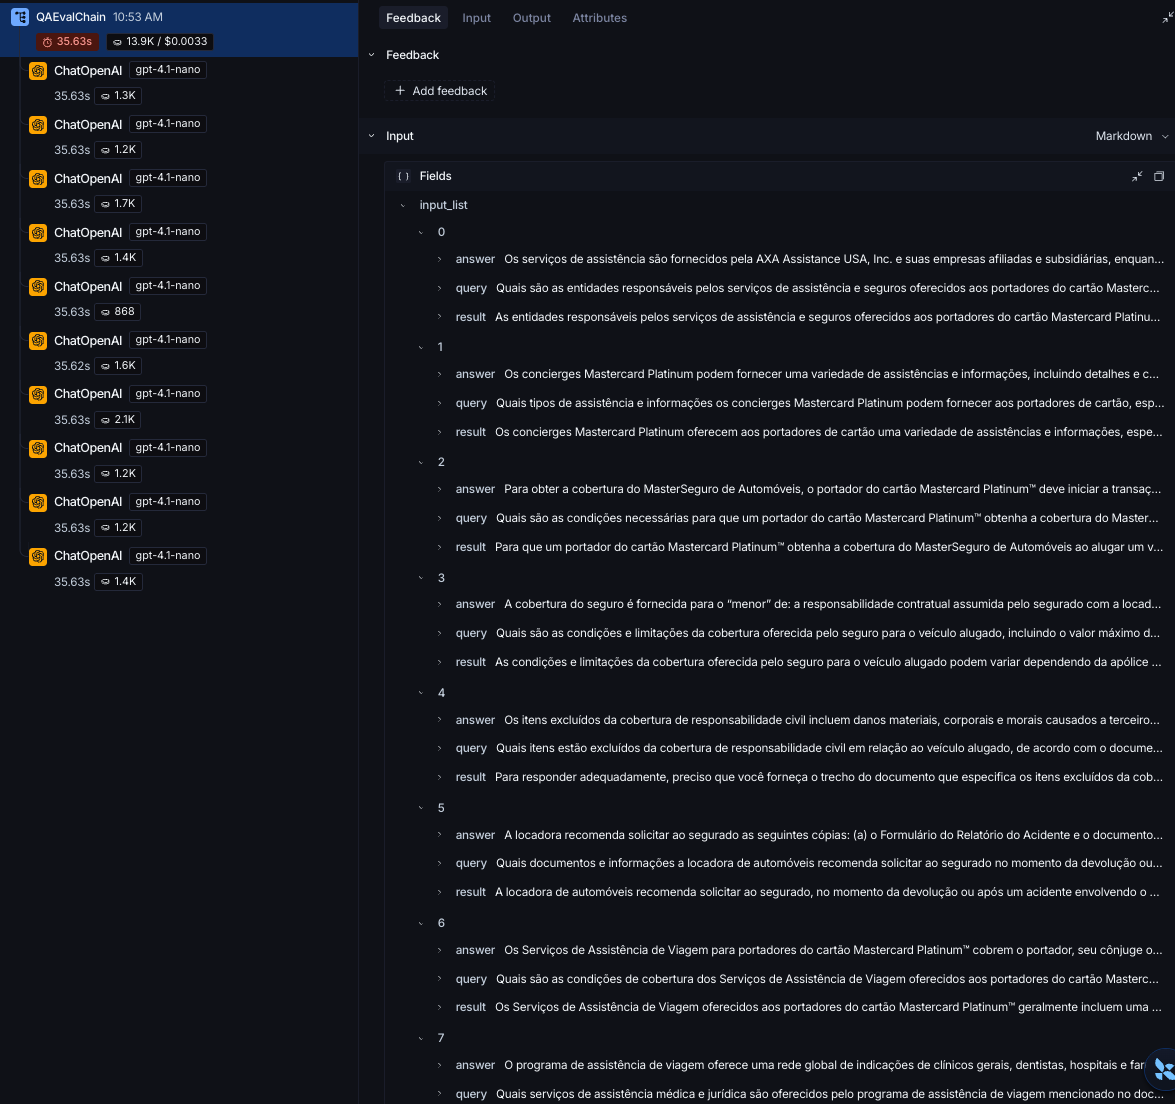


## Avaliação com RAG

In [84]:
geracoes_rag = []
for pr in perguntas_respostas[:10]:
    geracoes_rag.append({"result": rag_chain.invoke(pr["query"])})

In [85]:
geracoes_rag

[{'result': 'Com base nos documentos fornecidos, as seguintes entidades são responsáveis pelos serviços de assistência e seguros oferecidos aos portadores do cartão Mastercard Platinum™:\n\n*   **AIG:** A AIG fornece a cobertura de seguro como parte do programa MasterSeguro de Automóveis (Veículo Alugado Protegido).\n*   **Mastercard:** A Mastercard é a responsável por oferecer a cobertura através do cartão Platinum™. Ela também é envolvida no processo de pagamento das despesas e na opção de usar pontos de recompensa para cobrir custos.\n\n**Papel da Mastercard:**\n\n*   É a entidade que oferece a cobertura ao portador do cartão Platinum™ ao alugar um veículo.\n*   Processa os pagamentos do depósito de garantia da locadora e das despesas médicas, especialmente através da opção de "Sem Desembolso de Dinheiro".\n*   Permite o uso de pontos de recompensa da Mastercard para cobrir despesas de viagem.\n\n**Bilhete de Seguro:**\n\nÉ importante notar que, apesar da cobertura ser oferecida pel

In [86]:
avaliar(perguntas_respostas[:10], geracoes_rag)

GRADE: INCORRECT
GRADE: INCORRECT
GRADE: CORRECT
GRADE: INCORRECT
GRADE: INCORRECT
INCORRECT
GRADE: INCORRECT
GRADE: INCORRECT
INCORRECT
INCORRECT


/Users/devbodegami/Projetos/formacao-especialista-em-ia/.venv-test/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:564: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")


0.1

## Resultado avaliação com RAG

# Total:  10% de acerto
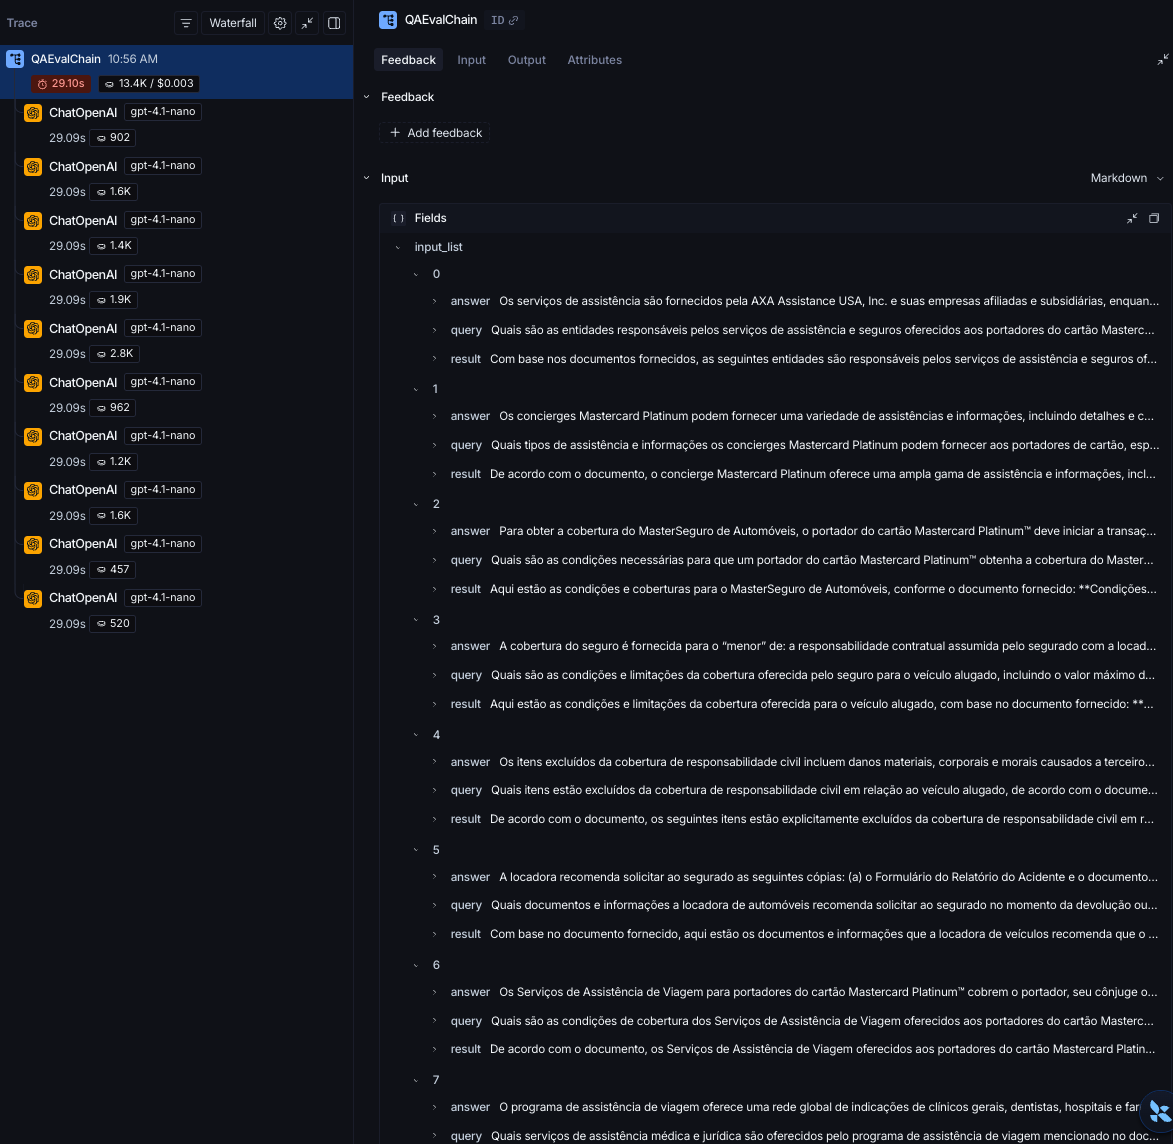

## Avaliação Multi Query com Rag

In [88]:
geracoes_multi_rag = []
for pr in perguntas_respostas[:10]:
    geracoes_multi_rag.append({"result": multi_rag_chain.invoke(pr["query"])})

In [89]:
avaliar(perguntas_respostas[:10], geracoes_multi_rag)

GRADE: INCORRECT
GRADE: INCORRECT
GRADE: INCORRECT
INCORRECT
GRADE: INCORRECT
GRADE: INCORRECT
GRADE: INCORRECT
GRADE: INCORRECT
GRADE: INCORRECT
GRADE: INCORRECT


/Users/devbodegami/Projetos/formacao-especialista-em-ia/.venv-test/lib/python3.12/site-packages/langchain_openai/chat_models/base.py:564: UserWarning: Unexpected type for token usage: <class 'NoneType'>
  warnings.warn(f"Unexpected type for token usage: {type(new_usage)}")


0.0

## Resultado avaliação multi query com RAG

# Total: 0% de acerto
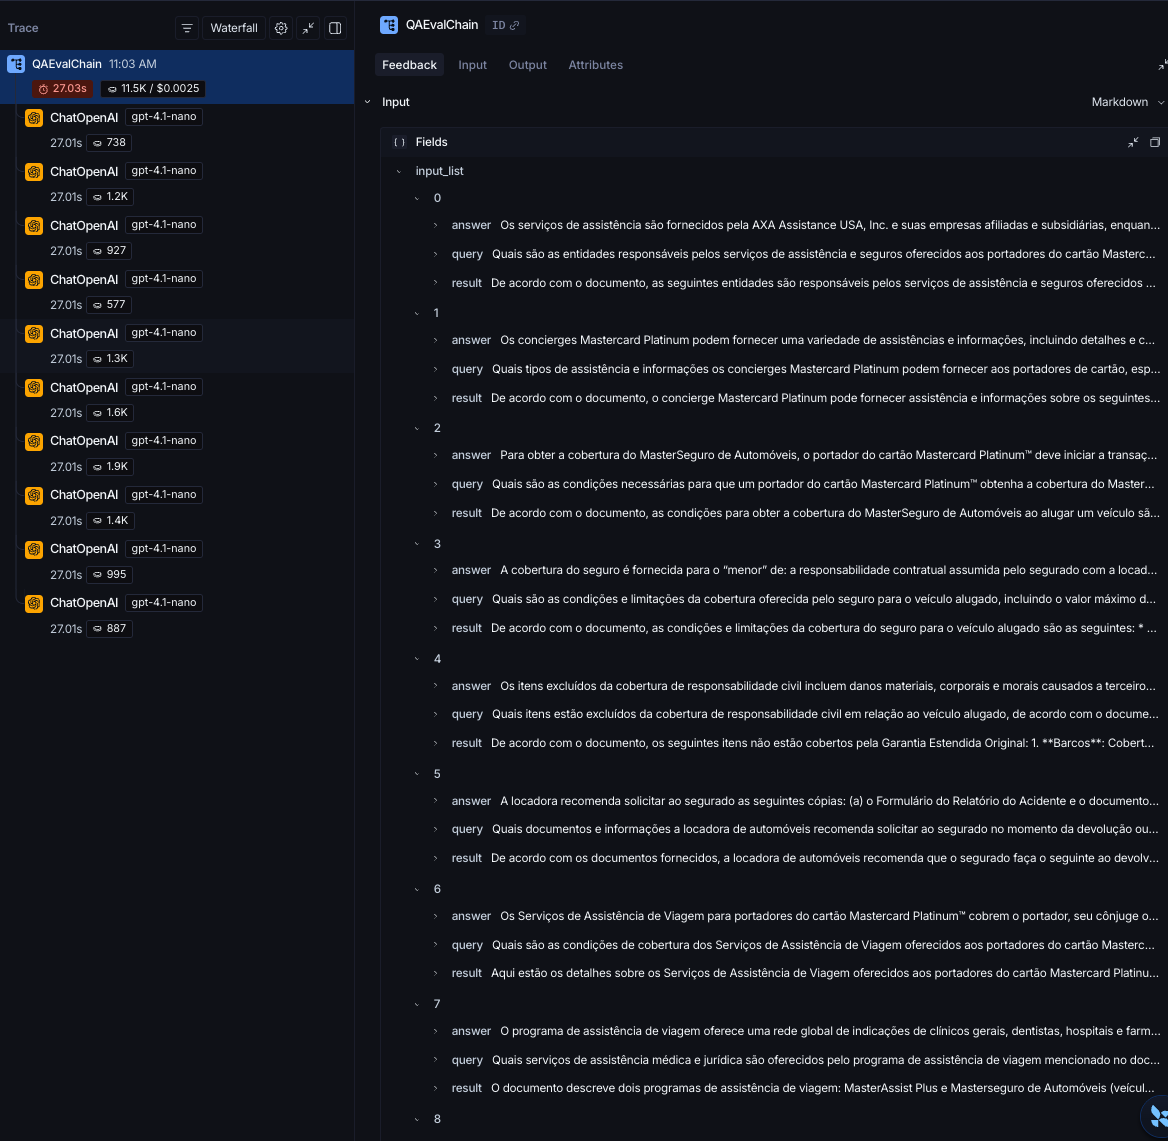

#### Os resultados indicam que, mesmo enriquecimento o prompt com rag e multi rag, a qualidade nas respostas caiu muito, levando a crer que o problema pode estar na forma em que recuperamos esses dados e montamos o prompt com eles ou no proprio RAG em si.